In [2]:
import ocha_stratus as stratus
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv  

load_dotenv()

True

In [3]:
gdf_flood_sel = stratus.load_geoparquet_from_blob("ds-aa-nga-flooding/processed/groundsource_flood_sel.parquet")
print(f"Loaded {len(gdf_flood_sel)} flood polygons from blob")

Loaded 3174 flood polygons from blob


In [4]:
import geopandas as gpd
from src.datasources import nihsa, hydrosheds

gdf_nga = stratus.codab.load_codab_from_blob("NGA", admin_level=0)
gdf_lga_sel = stratus.load_geoparquet_from_blob("ds-aa-nga-flooding/processed/selected_lgas.parquet")

gdf_hydrological_areas = nihsa.load_hydological_areas()
if gdf_hydrological_areas.crs is None:
    gdf_hydrological_areas = gdf_hydrological_areas.set_crs(epsg=4326)
gdf_rivers = hydrosheds.load_selected_rivers()
gdf_rivers_ha = gpd.clip(gdf_rivers, gdf_hydrological_areas.union_all())

xmin, ymin, xmax, ymax = gdf_lga_sel.total_bounds

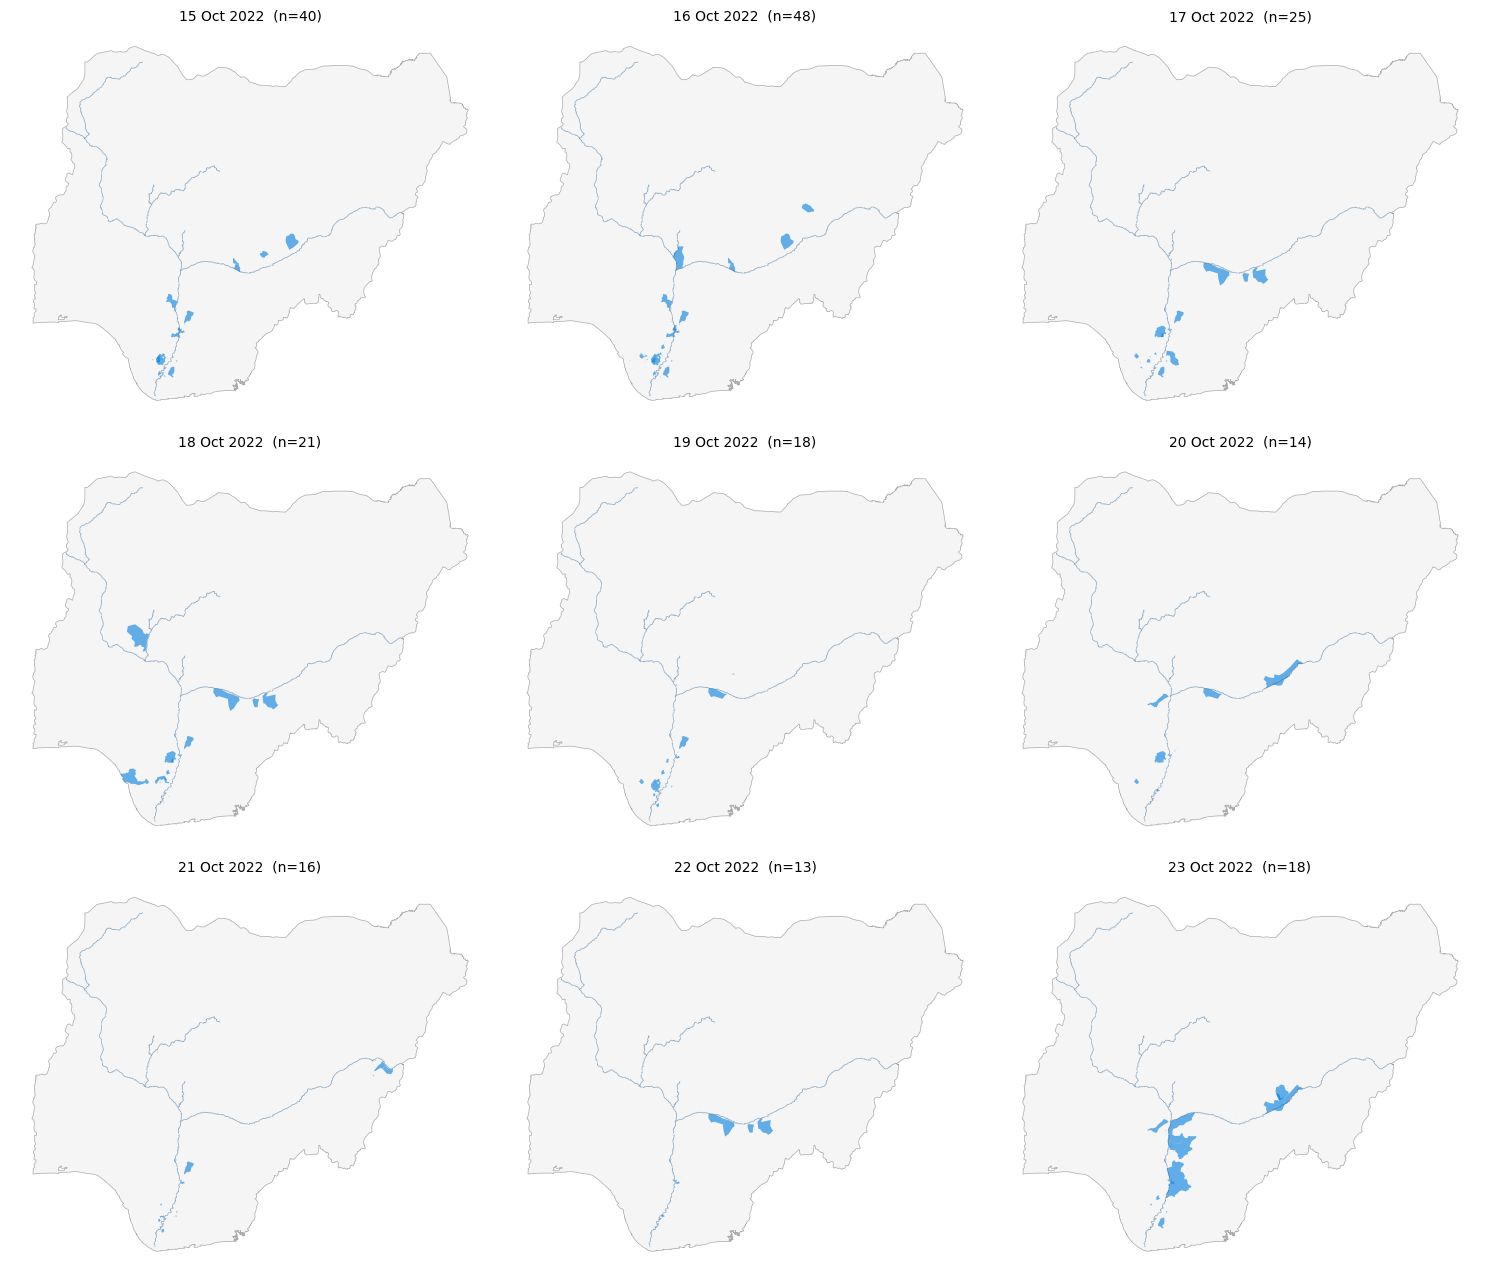

In [5]:
# --- 3x3 faceted map: active groundsource flood polygons per day ---
start_date = "2022-10-15"  # change to explore — generates 9 consecutive days

dates_9 = pd.date_range(start_date, periods=9, freq="D")

fig, axes = plt.subplots(3, 3, figsize=(15, 13))

for ax, date in zip(axes.flat, dates_9):
    # Polygons active on this day
    active = gdf_flood_sel[
        (gdf_flood_sel["start_date"] <= date) & (gdf_flood_sel["end_date"] >= date)
    ]

    gdf_nga.plot(ax=ax, facecolor="#f5f5f5", edgecolor="#aaaaaa", linewidth=0.5)

    if len(active) > 0:
        active.plot(ax=ax, facecolor="#007CE0", edgecolor="none", alpha=0.6, zorder=3)

    gdf_rivers_ha.plot(ax=ax, color="#1E5A8E", linewidth=0.5, alpha=0.5, zorder=4)

    ax.set_title(f"{date.strftime('%d %b %Y')}  (n={len(active)})", fontsize=10)
    ax.set_axis_off()

plt.tight_layout()
plt.savefig(f"figures/groundsource_grid_{start_date}.png", dpi=200, bbox_inches="tight")

In [6]:
import ocha_stratus as stratus

gdf_adm2 = stratus.codab.load_codab_from_blob("NGA", admin_level=2)
gdf_groundsource = stratus.load_geoparquet_from_blob("vector/raw/groundsource_2026.parquet", container_name="global")

In [7]:
xmin, ymin, xmax, ymax = gdf_adm2.total_bounds
gdf_groundsource_nga = gdf_groundsource.cx[xmin:xmax, ymin:ymax]

In [8]:
gdf_adm2_proj = gdf_adm2.to_crs(epsg=32632)
gdf_flood_proj = gdf_groundsource_nga.to_crs(epsg=32632)

gdf_adm2_proj["lga_area"] = gdf_adm2_proj.geometry.area

gdf_intersection = gpd.overlay(gdf_adm2_proj, gdf_flood_proj, how="intersection")
gdf_intersection["overlap_frac"] = (
    gdf_intersection.geometry.area
    / gdf_intersection["ADM2_PCODE"].map(gdf_adm2_proj.set_index("ADM2_PCODE")["lga_area"])
)
gdf_intersection = gdf_intersection[gdf_intersection["overlap_frac"] >= 0.10]
gdf_intersection

,ADM2_EN,ADM2_PCODE,ADM1_EN,ADM1_PCODE,ADM0_EN,ADM0_PCODE,DATE,VALIDON,VALIDTO,lga_area,uuid,area_km2,start_date,end_date,geometry,overlap_frac
0,Aba North,NG001001,Abia,NG001,Nigeria,NG,2016-11-29,2019-04-17,NaT,1.868551e+07,778ebf4fa85645d2ad031a507929c551,3.259849,2007-07-26,2007-07-26,"POLYGON ((316483.686 564006.664, 316266.055 56...",0.128823
3,Aba North,NG001001,Abia,NG001,Nigeria,NG,2016-11-29,2019-04-17,NaT,1.868551e+07,07df818050234840a7ead004be8d34f5,3.259849,2016-06-05,2016-06-05,"POLYGON ((316483.686 564006.664, 316266.055 56...",0.128823
6,Aba North,NG001001,Abia,NG001,Nigeria,NG,2016-11-29,2019-04-17,NaT,1.868551e+07,5d9d8ee7e25441aea1389a70ae038b90,196.798350,2017-06-26,2017-06-26,"POLYGON ((322464.678 562009.602, 322211.841 56...",1.000000
7,Aba North,NG001001,Abia,NG001,Nigeria,NG,2016-11-29,2019-04-17,NaT,1.868551e+07,b448f32e8c9646889c42a356b2b86e68,17.864117,2017-07-23,2017-07-23,"POLYGON ((322464.678 562009.602, 322211.841 56...",0.617056
9,Aba North,NG001001,Abia,NG001,Nigeria,NG,2016-11-29,2019-04-17,NaT,1.868551e+07,6ad3f6d99ac84e2485a751de1b5943f0,196.798350,2017-07-23,2017-07-23,"POLYGON ((322464.678 562009.602, 322211.841 56...",1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43299,Zuru,NG022021,Kebbi,NG022,Nigeria,NG,2016-11-29,2019-04-17,NaT,6.996606e+08,91a78abe89484af58eb5e45a1cc1c529,3309.532497,2020-08-26,2020-08-26,"POLYGON ((105264.226 1262166.821, 104275.505 1...",0.174000
43300,Zuru,NG022021,Kebbi,NG022,Nigeria,NG,2016-11-29,2019-04-17,NaT,6.996606e+08,60bedff1c0934a3fa1f8370bac5f2032,3309.532497,2020-08-30,2020-08-31,"POLYGON ((105264.226 1262166.821, 104275.505 1...",0.174000
43302,Zuru,NG022021,Kebbi,NG022,Nigeria,NG,2016-11-29,2019-04-17,NaT,6.996606e+08,2ba3cad942b34b51a1cdc6477b686e32,3309.532497,2020-09-03,2020-09-03,"POLYGON ((105264.226 1262166.821, 104275.505 1...",0.174000
43306,Zuru,NG022021,Kebbi,NG022,Nigeria,NG,2016-11-29,2019-04-17,NaT,6.996606e+08,030c5c40574c4756a321a92c8dadcfec,3309.532497,2020-09-19,2020-09-19,"POLYGON ((105264.226 1262166.821, 104275.505 1...",0.174000


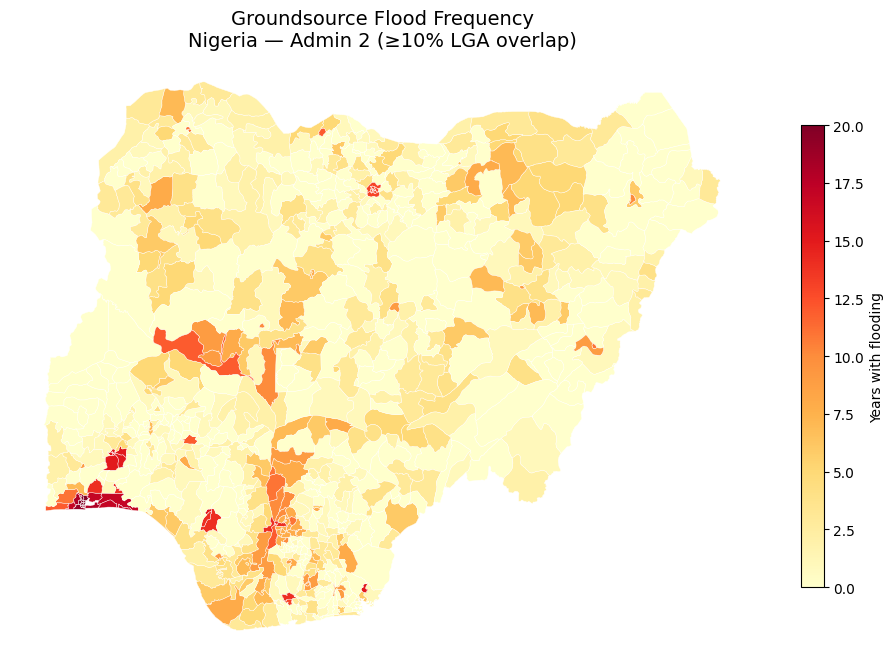

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

gdf_intersection["year"] = pd.to_datetime(gdf_intersection["start_date"]).dt.year

df_freq = (
    gdf_intersection.groupby("ADM2_PCODE")["year"]
    .nunique()
    .reset_index()
    .rename(columns={"year": "years_flooded"})
)

gdf_freq = gdf_adm2.merge(df_freq, on="ADM2_PCODE", how="left")
gdf_freq["years_flooded"] = gdf_freq["years_flooded"].fillna(0)

fig, ax = plt.subplots(figsize=(12, 10))
gdf_freq.plot(
    column="years_flooded",
    ax=ax,
    cmap="YlOrRd",
    legend=True,
    legend_kwds={"label": "Years with flooding", "shrink": 0.6},
    edgecolor="white",
    linewidth=0.3,
)
ax.set_title("Groundsource Flood Frequency\nNigeria — Admin 2 (≥10% LGA overlap)", fontsize=14)
ax.axis("off")
plt.savefig("figures/groundsource_flood_frequency.png", dpi=300, bbox_inches="tight")

In [10]:
stratus.upload_parquet_to_blob(
    df_freq.rename(columns={"years_flooded": "groundsource_years_flooded"}),
    "ds-aa-nga-flooding/processed/web_map/groundsource_years_flooded.parquet",
)